In [9]:
import pandas as pd

# Load the main dataset using ISO-8859-1 encoding to avoid errors with special characters
file_path = '/Users/fernando/DataCoSupplyChainDataset.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# --- 1. DATA SELECTION ---
# Selecting the most relevant columns for Supply Chain Efficiency & Inventory analysis
relevant_columns = [
    'Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Delivery Status', 'Late_delivery_risk', 'Category Name', 
    'Order Item Quantity', 'Sales', 'Order Item Total', 'Product Price',
    'Shipping Mode'  # <-- ESSA LINHA É A QUE ESTAVA FALTANDO NO SEU NOVO NOTEBOOK
]

df_clean = df[relevant_columns].copy()

# --- 2. CALCULATING SHIPPING PERFORMANCE ---
# Measuring the gap between scheduled and real delivery days
df_clean['Shipping_Delay'] = df_clean['Days for shipping (real)'] - df_clean['Days for shipment (scheduled)']

# --- 3. BASIC INSPECTION ---
print("--- DataCo Supply Chain Dataset Loaded Successfully ---")
print(df_clean[['Category Name', 'Delivery Status', 'Shipping_Delay']].head())
print("\n--- Dataset Info ---")
print(df_clean.info())

--- DataCo Supply Chain Dataset Loaded Successfully ---
    Category Name   Delivery Status  Shipping_Delay
0  Sporting Goods  Advance shipping              -1
1  Sporting Goods     Late delivery               1
2  Sporting Goods  Shipping on time               0
3  Sporting Goods  Advance shipping              -1
4  Sporting Goods  Advance shipping              -2

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Delivery Status                180519 non-null  object 
 4   Late_delivery_risk             180519 non-null  int64  
 5   Category Name                  180519 non-null  object 
 6   Order 

In [10]:
# --- 4. LOGISTICS EFFICIENCY ANALYSIS ---

# Calculating the percentage of late deliveries per product category
# This shows which products have the most problematic supply chains
late_delivery_analysis = df_clean.groupby('Category Name').agg({
    'Late_delivery_risk': 'mean',
    'Sales': 'sum',
    'Shipping_Delay': 'mean'
}).reset_index()

# Converting risk to percentage for easier executive reading
late_delivery_analysis['Late_Risk_%'] = late_delivery_analysis['Late_delivery_risk'] * 100

# Filtering only the Top 10 categories by total Sales to focus on what matters
top_10_categories = late_delivery_analysis.sort_values(by='Sales', ascending=False).head(10)

# --- 5. SHIPPING METHOD PERFORMANCE ---

# Analyzing delivery status distribution
delivery_status_count = df_clean['Delivery Status'].value_counts(normalize=True) * 100

print("--- Top 10 Categories: Sales vs. Late Delivery Risk ---")
print(top_10_categories[['Category Name', 'Sales', 'Late_Risk_%', 'Shipping_Delay']])

print("\n--- Overall Delivery Status Distribution (%) ---")
print(delivery_status_count)

--- Top 10 Categories: Sales vs. Late Delivery Risk ---
           Category Name         Sales  Late_Risk_%  Shipping_Delay
18               Fishing  6.929654e+06    54.926407        0.555152
12                Cleats  4.431943e+06    54.971284        0.576962
9       Camping & Hiking  4.118426e+06    54.534198        0.551388
10      Cardio Equipment  3.694843e+06    54.496677        0.554337
47       Women's Apparel  3.147800e+06    54.556691        0.559544
46          Water Sports  3.113845e+06    54.806950        0.567310
34        Men's Footwear  2.891758e+06    54.486200        0.564191
30  Indoor/Outdoor Games  2.888994e+06    54.746606        0.564722
38         Shop By Sport  1.309522e+06    55.152950        0.575291
13             Computers  6.630000e+05    50.678733        0.454751

--- Overall Delivery Status Distribution (%) ---
Delivery Status
Late delivery        54.829132
Advance shipping     23.040234
Shipping on time     17.835242
Shipping canceled     4.295393
Name: 

In [11]:
# --- 6. FINANCIAL IMPACT OF LOGISTICS FAILURES ---

# Calculating total revenue at risk (Sales from late or canceled deliveries)
revenue_at_risk = df_clean.groupby('Delivery Status')['Sales'].sum().reset_index()

# Formatting for better readability
revenue_at_risk['Sales_Millions'] = revenue_at_risk['Sales'] / 1_000_000

# --- 7. ORDER QUANTITY ANALYSIS (Inventory Velocity) ---

# Analyzing if larger orders (more items) lead to more delays
# High order quantity items usually require more warehouse handling time
quantity_vs_delay = df_clean.groupby('Order Item Quantity').agg({
    'Late_delivery_risk': 'mean',
    'Shipping_Delay': 'mean'
}).reset_index()

print("--- Revenue at Risk by Delivery Status (In Millions) ---")
print(revenue_at_risk[['Delivery Status', 'Sales_Millions']])

print("\n--- Impact of Order Quantity on Delays ---")
print(quantity_vs_delay.head(5))

--- Revenue at Risk by Delivery Status (In Millions) ---
     Delivery Status  Sales_Millions
0   Advance shipping        8.518008
1      Late delivery       20.126395
2  Shipping canceled        1.570305
3   Shipping on time        6.570026

--- Impact of Order Quantity on Delays ---
   Order Item Quantity  Late_delivery_risk  Shipping_Delay
0                    1            0.548803        0.564761
1                    2            0.543392        0.558110
2                    3            0.551155        0.567469
3                    4            0.548168        0.571084
4                    5            0.547952        0.571646


In [12]:
# --- 8. INVENTORY PRIORITIZATION (ABC ANALYSIS) ---

# Classify categories based on their contribution to total Revenue
# Class A: Top 20% of categories responsible for 80% of revenue (The Pareto Principle)
category_revenue = df_clean.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).reset_index()
category_revenue['Cumulative_Sales'] = category_revenue['Sales'].cumsum()
total_sales = category_revenue['Sales'].sum()
category_revenue['Sales_Share_%'] = (category_revenue['Cumulative_Sales'] / total_sales) * 100

# Defining Classes
def abc_classification(percent):
    if percent <= 80: return 'A-Class (High Priority)'
    elif percent <= 95: return 'B-Class (Medium Priority)'
    else: return 'C-Class (Low Priority)'

category_revenue['ABC_Class'] = category_revenue['Sales_Share_%'].apply(abc_classification)

# --- 9. LEAD TIME RELIABILITY ---
# Checking which categories have the most unpredictable shipping (Standard Deviation of Delay)
lead_time_variance = df_clean.groupby('Category Name')['Shipping_Delay'].std().sort_values(ascending=False).reset_index()

print("--- ABC Classification: Revenue Concentration ---")
print(category_revenue[['Category Name', 'Sales', 'ABC_Class']].head(10))

print("\n--- Top 5 Most Unpredictable Categories (Shipping Variance) ---")
print(lead_time_variance.head(5))

--- ABC Classification: Revenue Concentration ---
          Category Name         Sales                  ABC_Class
0               Fishing  6.929654e+06    A-Class (High Priority)
1                Cleats  4.431943e+06    A-Class (High Priority)
2      Camping & Hiking  4.118426e+06    A-Class (High Priority)
3      Cardio Equipment  3.694843e+06    A-Class (High Priority)
4       Women's Apparel  3.147800e+06    A-Class (High Priority)
5          Water Sports  3.113845e+06    A-Class (High Priority)
6        Men's Footwear  2.891758e+06    A-Class (High Priority)
7  Indoor/Outdoor Games  2.888994e+06  B-Class (Medium Priority)
8         Shop By Sport  1.309522e+06  B-Class (Medium Priority)
9             Computers  6.630000e+05  B-Class (Medium Priority)

--- Top 5 Most Unpredictable Categories (Shipping Variance) ---
          Category Name  Shipping_Delay
0            Basketball        1.735181
1    Women's Golf Clubs        1.647626
2       As Seen on  TV!        1.635523
3         

In [13]:
# --- 10. STRATEGIC RECOMMENDATIONS: SAFETY STOCK ---

# Calculate a simple Safety Stock Factor based on Delay Variance
# High Variance = Need more Safety Stock to avoid stockouts
recommendations = category_revenue.merge(lead_time_variance, on='Category Name')

# Safety Stock Factor = Variance of Delay * 1.5 (Buffer for uncertainty)
recommendations['Suggested_Safety_Stock_Days'] = recommendations['Shipping_Delay'] * 1.5

# Focus only on A-Class items for the final report
a_class_plan = recommendations[recommendations['ABC_Class'] == 'A-Class (High Priority)'].sort_values(by='Sales', ascending=False)

print("--- RECOVERY PLAN: Suggested Safety Stock for A-Class ---")
print(a_class_plan[['Category Name', 'ABC_Class', 'Suggested_Safety_Stock_Days']])

# --- 11. FINAL EXPORT FOR LOGISTICS DASHBOARD ---
df_clean.to_csv('/Users/fernando/supply_chain_analysis_final.csv', index=False)

print("\n--- Project Status: Logistics Audit Complete ---")
print("Cleaned file saved as 'supply_chain_analysis_final.csv'")

--- RECOVERY PLAN: Suggested Safety Stock for A-Class ---
      Category Name                ABC_Class  Suggested_Safety_Stock_Days
0           Fishing  A-Class (High Priority)                     2.242007
1            Cleats  A-Class (High Priority)                     2.236658
2  Camping & Hiking  A-Class (High Priority)                     2.228775
3  Cardio Equipment  A-Class (High Priority)                     2.228165
4   Women's Apparel  A-Class (High Priority)                     2.228543
5      Water Sports  A-Class (High Priority)                     2.228592
6    Men's Footwear  A-Class (High Priority)                     2.237662

--- Project Status: Logistics Audit Complete ---
Cleaned file saved as 'supply_chain_analysis_final.csv'


/var/folders/q4/vfsqdvdx2ls8d0z4yhxfxc1w0000gn/T/ipykernel_59994/2627309184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=top_10_filtered, x='Late_Risk_%', y='Category Name', palette='Reds_r')


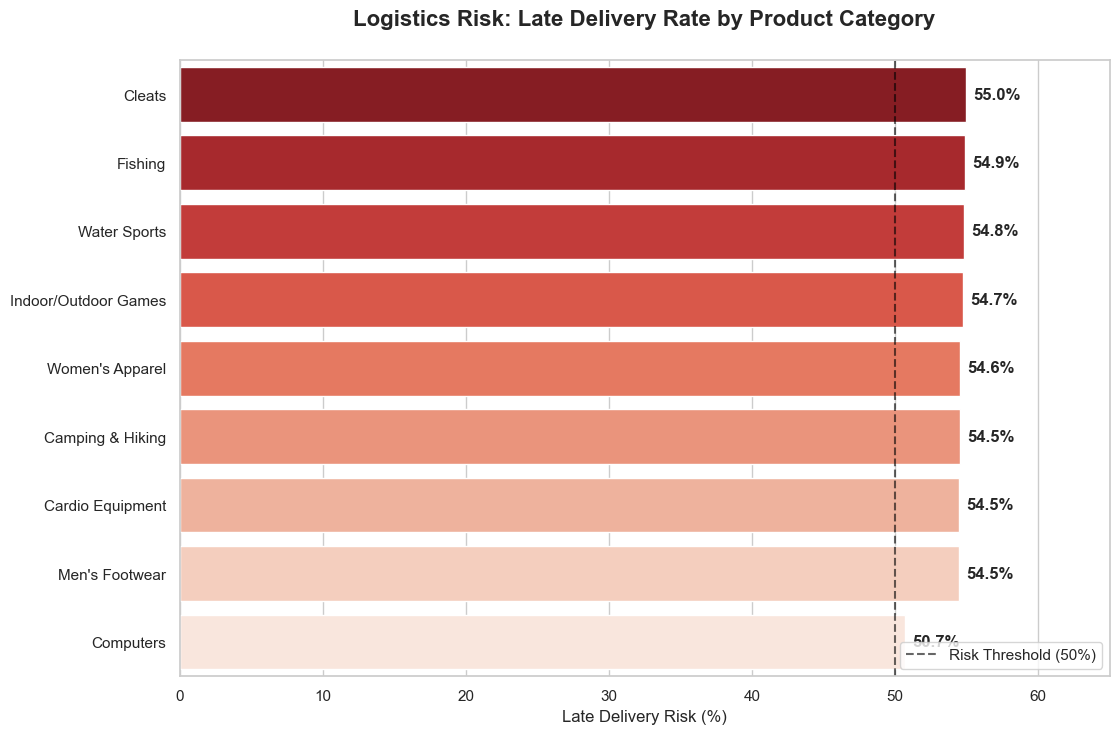

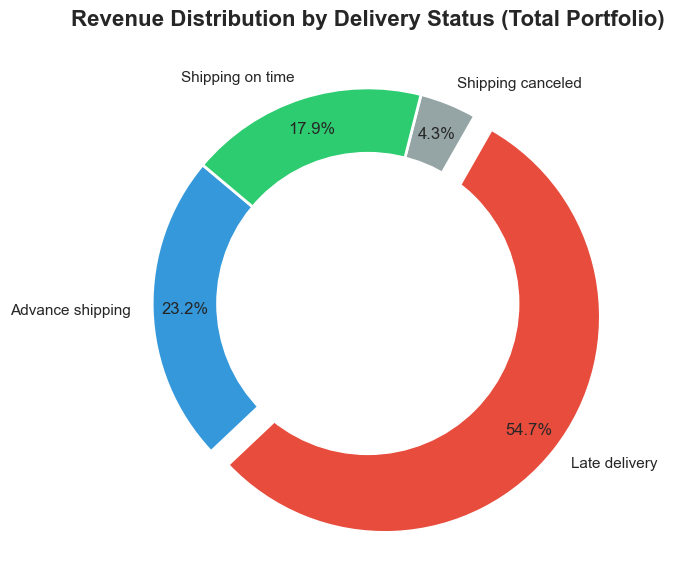

/var/folders/q4/vfsqdvdx2ls8d0z4yhxfxc1w0000gn/T/ipykernel_59994/2627309184.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=a_class_sorted, x='Category Name', y='Suggested_Safety_Stock_Days', palette='mako')


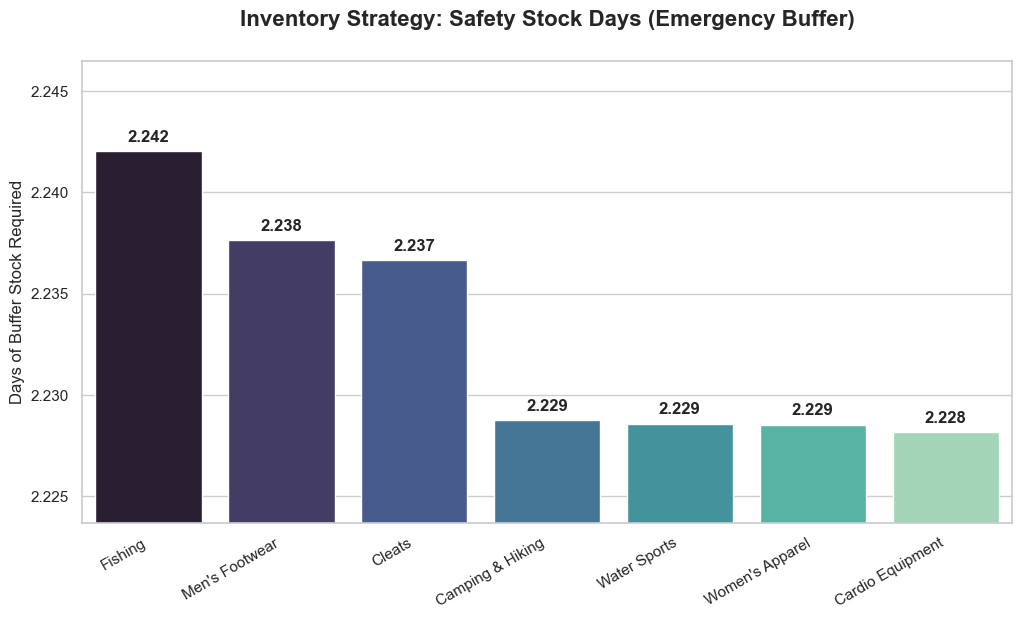

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- 12. LOGISTICS RISK ---
categories_to_remove = ['Shop By Sport']
top_10_filtered = top_10_categories[~top_10_categories['Category Name'].isin(categories_to_remove)]
top_10_filtered = top_10_filtered.sort_values(by='Late_Risk_%', ascending=False)

plt.figure(figsize=(12, 8))
ax1 = sns.barplot(data=top_10_filtered, x='Late_Risk_%', y='Category Name', palette='Reds_r')

plt.title('Logistics Risk: Late Delivery Rate by Product Category', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Late Delivery Risk (%)', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xlim(0, 65)
plt.axvline(50, color='black', linestyle='--', alpha=0.6, label='Risk Threshold (50%)')

for p in ax1.patches:
    width = p.get_width()
    ax1.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center', fontweight='bold')

plt.legend(loc='lower right')
plt.savefig('/Users/fernando/logistics_risk_v3.png', bbox_inches='tight')
plt.show()

# --- 13. REVENUE AT RISK: FINANCIAL IMPACT PIE ---
plt.figure(figsize=(10, 7))
colors = ["#3498db", "#e74c3c", "#95a5a6", "#2ecc71"] # Blue, Red, Grey, Green
explode = (0, 0.1, 0, 0) # Highlighting the Late Delivery slice

plt.pie(
    revenue_at_risk['Sales_Millions'], 
    labels=revenue_at_risk['Delivery Status'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    explode=explode, 
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Adding a circle at the center to make it a Donut Chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Revenue Distribution by Delivery Status (Total Portfolio)', fontsize=16, fontweight='bold')
plt.savefig('/Users/fernando/revenue_impact_final.png', bbox_inches='tight')
plt.show()

# --- 14. INVENTORY STRATEGY: SAFETY STOCK ---
plt.figure(figsize=(12, 6))

# Sorting to show where safety stock should be higher
a_class_sorted = a_class_plan.sort_values(by='Suggested_Safety_Stock_Days', ascending=False)

ax2 = sns.barplot(data=a_class_sorted, x='Category Name', y='Suggested_Safety_Stock_Days', palette='mako')

# Applying the "Zoom" to highlight the strategic differences between 2.22 and 2.24 days
min_val = a_class_sorted['Suggested_Safety_Stock_Days'].min() * 0.998
max_val = a_class_sorted['Suggested_Safety_Stock_Days'].max() * 1.002
plt.ylim(min_val, max_val)

plt.title('Inventory Strategy: Safety Stock Days (Emergency Buffer)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Days of Buffer Stock Required', fontsize=12)
plt.xlabel('', fontsize=12)
plt.xticks(rotation=30, ha='right')

# Adding the exact values
for p in ax2.patches:
    ax2.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', 
                fontweight='bold')

plt.savefig('/Users/fernando/safety_stock_v3.png', bbox_inches='tight')
plt.show()

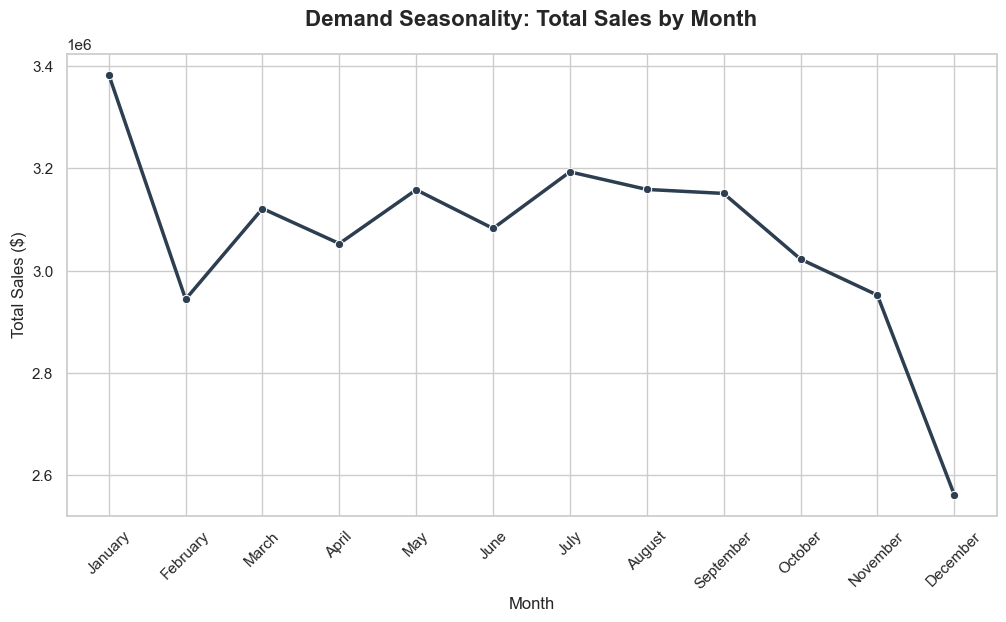

--- Shipping Mode Reliability (%) ---
Shipping Mode
Standard Class    38.071683
Same Day          45.743042
Second Class      76.632781
First Class       95.322499
Name: Late_delivery_risk, dtype: float64


In [15]:
# --- 15. TIME-SERIES ANALYSIS: SALES SEASONALITY ---

# Converting the order date to a proper datetime format
df['order_date'] = pd.to_datetime(df['shipping date (DateOrders)'])

# Extracting Month and Day of the Week
df['order_month'] = df['order_date'].dt.month_name()
df['order_day'] = df['order_date'].dt.day_name()

# Sorting months correctly for the chart
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Calculating monthly sales trend
monthly_sales = df.groupby('order_month')['Sales'].sum().reindex(month_order).reset_index()

# Visualizing the Sales Trend (The "Seasonality" Chart)
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='order_month', y='Sales', marker='o', color='#2c3e50', linewidth=2.5)

plt.title('Demand Seasonality: Total Sales by Month', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)

plt.savefig('/Users/fernando/sales_seasonality.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 16. DELIVERY RISK BY SHIPPING MODE ---
# Does 'First Class' shipping actually arrive on time?
shipping_mode_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values() * 100

print("--- Shipping Mode Reliability (%) ---")
print(shipping_mode_risk)

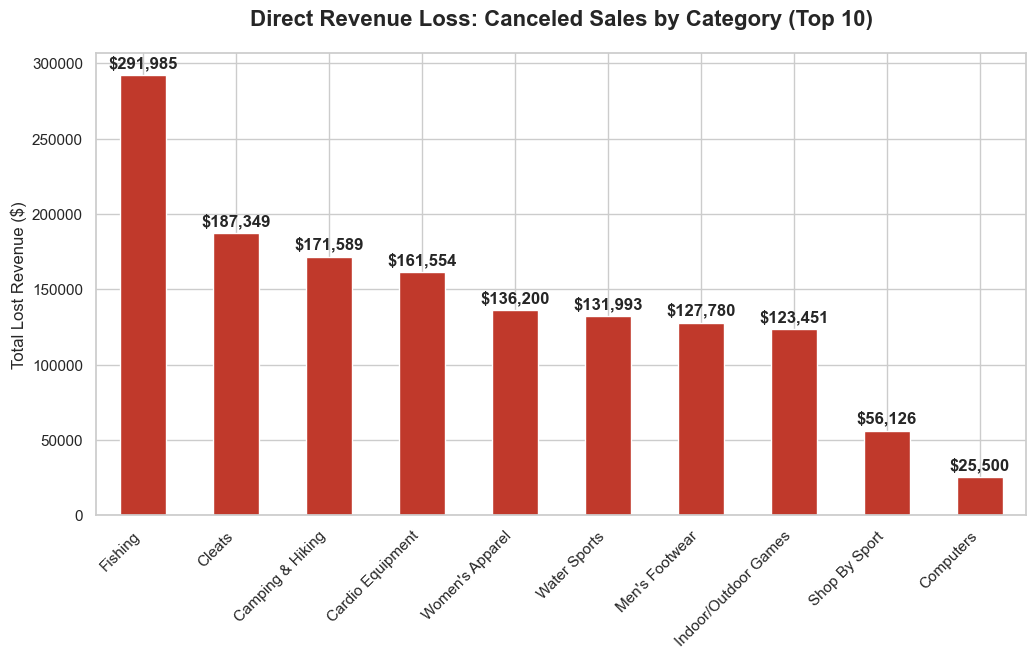

--- CARRIER PERFORMANCE SCORECARD (0 to 10) ---
High score = Reliable / Low score = Critical Failure
--------------------------------------------------
 Shipping Mode  Efficiency_Score
Standard Class          6.192832
      Same Day          5.425696
  Second Class          2.336722
   First Class          0.467750


In [16]:
# --- 17. FINANCIAL LOSS BY CATEGORY (REAL MONEY WASTED) ---
# Calculating how much money was lost in canceled sales by category
lost_revenue = df_clean[df_clean['Delivery Status'] == 'Shipping canceled'].groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = lost_revenue.plot(kind='bar', color='#c0392b') # Vermelho sóbrio

plt.title('Direct Revenue Loss: Canceled Sales by Category (Top 10)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Total Lost Revenue ($)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

# Adding dollar value labels to the bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

plt.savefig('/Users/fernando/financial_loss_category.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 18. CARRIER SCORECARD (PERFORMANCE METRIC 0–10) ---
# Creating a score based on punctuality (The more delay, the lower the score)
# Score = 10 - (Delay Risk * 10)
carrier_performance = df_clean.groupby('Shipping Mode')['Late_delivery_risk'].mean().reset_index()
carrier_performance['Efficiency_Score'] = (1 - carrier_performance['Late_delivery_risk']) * 10
carrier_performance = carrier_performance.sort_values(by='Efficiency_Score', ascending=False)

print("--- CARRIER PERFORMANCE SCORECARD (0 to 10) ---")
print("High score = Reliable / Low score = Critical Failure")
print("-" * 50)
print(carrier_performance[['Shipping Mode', 'Efficiency_Score']].to_string(index=False))